<a href="https://colab.research.google.com/github/KRANGED/Challenge-Telecom-X-an-lisis-de-evasi-n-de-clientes-Parte-1-/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [2]:
import pandas as pd
df_telecomx = pd.read_json('TelecomX_Data.json')
df_telecomx

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [3]:
n_customer = pd.json_normalize(df_telecomx['customer'])
n_phone = pd.json_normalize(df_telecomx['phone'])
n_internet = pd.json_normalize(df_telecomx['internet'])
n_account = pd.json_normalize(df_telecomx['account'])

dfn_telecomx = pd.concat([df_telecomx['customerID'],df_telecomx['Churn'], n_customer,n_phone, n_internet, n_account ], axis=1)
dfn_telecomx
# Finalmente, se pueden eliminar las columnas originales anidadas si ya no las necesitas
#df.drop(['columna1', 'columna2'], axis=1, inplace=True

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


### 2. Identificar valores duplicados en una columna específica
Si quieres encontrar valores duplicados dentro de una columna en particular (por ejemplo, `customerID`), también puedes usar `.duplicated()` en esa Serie específica. Esto te ayudará a ver si hay clientes con el mismo ID, lo cual podría indicar un problema de datos.

In [4]:
# Contar el número de filas completamente duplicadas
num_duplicate_rows = dfn_telecomx.duplicated().sum()
print(f"Número de filas completamente duplicadas: {num_duplicate_rows}")

# Mostrar las filas completamente duplicadas (todas las ocurrencias excepto la primera)
duplicate_rows = dfn_telecomx[dfn_telecomx.duplicated(keep=False)]
print("\nFilas completamente duplicadas (todas las ocurrencias):")
display(duplicate_rows)

Número de filas completamente duplicadas: 0

Filas completamente duplicadas (todas las ocurrencias):


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total


In [5]:
# Identificar IDs de cliente duplicados
duplicate_customer_ids = dfn_telecomx[dfn_telecomx['customerID'].duplicated(keep=False)]

print("Filas con 'customerID' duplicados (todas las ocurrencias):")
display(duplicate_customer_ids)

# Para ver solo los valores de customerID que están duplicados
duplicated_ids = dfn_telecomx[dfn_telecomx['customerID'].duplicated()]['customerID'].unique()
print(f"\nValores únicos de 'customerID' que están duplicados: {duplicated_ids}")

Filas con 'customerID' duplicados (todas las ocurrencias):


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total



Valores únicos de 'customerID' que están duplicados: []


In [6]:
dfn_telecomx.sample(10)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
3896,5327-CNLUQ,No,Male,0,Yes,No,48,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,No,Two year,Yes,Bank transfer (automatic),96.90,4473.45
2061,2900-PHPLN,No,Female,1,Yes,No,70,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.55,1462.05
6307,8676-OOQEJ,No,Male,0,No,No,4,No,No phone service,DSL,...,No,No,Yes,No,No,Month-to-month,No,Electronic check,30.50,118.4
5461,7483-IQWIB,No,Male,0,Yes,Yes,37,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,92.95,3415.25
239,0362-RAOQO,No,Female,0,No,No,40,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.65,830.25
6657,9146-JRIOX,No,Female,0,Yes,Yes,14,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,25.55,372.45
2329,3247-ZVOUO,Yes,Male,1,Yes,No,10,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,No,Electronic check,85.55,851.75
1910,2696-RZVZW,No,Male,0,Yes,No,68,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.05,1629.2
1250,1790-NESIO,No,Female,0,No,No,13,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,20.40,261.3
6242,8591-NXRCV,No,Female,0,No,No,41,Yes,Yes,DSL,...,No,Yes,Yes,No,Yes,Month-to-month,Yes,Bank transfer (automatic),74.65,3090.65


#🔧 Transformación

In [7]:
dfn_telecomx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [8]:
dfn_telecomx.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [9]:
for column in dfn_telecomx.columns:
    print(f"Column: {column}")
    print(dfn_telecomx[column].nunique())
    print(dfn_telecomx[column].unique())
    print("\n")

Column: customerID
7267
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']


Column: Churn
3
['No' 'Yes' '']


Column: gender
2
['Female' 'Male']


Column: SeniorCitizen
2
[0 1]


Column: Partner
2
['Yes' 'No']


Column: Dependents
2
['Yes' 'No']


Column: tenure
73
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]


Column: PhoneService
2
['Yes' 'No']


Column: MultipleLines
3
['No' 'Yes' 'No phone service']


Column: InternetService
3
['DSL' 'Fiber optic' 'No']


Column: OnlineSecurity
3
['No' 'Yes' 'No internet service']


Column: OnlineBackup
3
['Yes' 'No' 'No internet service']


Column: DeviceProtection
3
['No' 'Yes' 'No internet service']


Column: TechSupport
3
['Yes' 'No' 'No internet service']


Column: StreamingTV
3
['Yes' 'No' 'No internet service']


Column: StreamingM

## La columna Churn tiene datos en blanco (''), mientras que el tipo de dato en la columna Charges.Total no es flotante sino del tipo Object

In [10]:
#revisando valores duplicados
print(f'El DataFrame tiene :{dfn_telecomx.duplicated().sum()} valores duplicados')
#

El DataFrame tiene :0 valores duplicados


In [11]:
#revisando valores nulos
print(f'El DataFrame tiene :{dfn_telecomx.isnull().sum().sum()} valores nulos')
dfn_telecomx.isnull().sum()
#

El DataFrame tiene :0 valores nulos


,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [12]:
# comprobacion de valores en blanco
print(f'El DataFrame tiene :{dfn_telecomx.isin([""]).sum().sum()} valores en blanco')
# comprobando que tenga valores vacios o en blanco
dfn_telecomx.isin([""]).sum()

El DataFrame tiene :224 valores en blanco


,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [13]:
# Eliminar las filas donde 'Churn' es una cadena vacía ('')
dfn_telecomx = dfn_telecomx[dfn_telecomx['Churn'].str.strip() != '']
print(f'El nuevo numero de filas es: {len(dfn_telecomx['Churn'])}')

El nuevo numero de filas es: 7043


In [14]:
#verificacion de vacios o en blanco se empleó ese método porque ya habíamos visto que nuestro único valor vacío o blanco era ''
print(f'{dfn_telecomx.isin(['']).sum().sum()}')
dfn_telecomx.isin(['']).sum()

#si no se utilizaba este:
#dfn_telecomx.apply(lambda x: x.astype(str).str.strip() == '').sum()

0


,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [15]:
#convertir la columna Charges.Total a flotante
dfn_telecomx['Charges.Total'] = pd.to_numeric(dfn_telecomx['Charges.Total'],errors = 'coerce')
dfn_telecomx.dtypes

/tmp/ipykernel_342/3306277986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfn_telecomx['Charges.Total'] = pd.to_numeric(dfn_telecomx['Charges.Total'],errors = 'coerce')


,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [16]:
#Eliminar los 11 datos vacíos de 'Charges.Total'
dfn_telecomx.dropna(subset=['Charges.Total'],inplace =True)
dfn_telecomx.isnull().sum()

/tmp/ipykernel_342/3673303143.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfn_telecomx.dropna(subset=['Charges.Total'],inplace =True)


,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


### Opcional

Ahora que los datos están limpios, es momento de crear la columna "Cuentas_Diarias". Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

📌 Esta columna te ayudará a profundizar en el análisis y a obtener información valiosa para las siguientes etapas.

In [17]:
dfn_telecomx['Cuentas_Diarias'] = dfn_telecomx['Charges.Monthly'] / 30
dfn_telecomx

/tmp/ipykernel_342/1260803014.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfn_telecomx['Cuentas_Diarias'] = dfn_telecomx['Charges.Monthly'] / 30


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


### Estandarización y transformación de datos (Opcional)

La estandarización y transformación de datos es una etapa opcional, pero altamente recomendada, ya que busca hacer que la información sea más consistente, comprensible y adecuada para el análisis. Durante esta fase, por ejemplo, puedes convertir valores textuales como "Sí" y "No" en valores binarios (1 y 0), lo que facilita el procesamiento matemático y la aplicación de modelos analíticos.

Además, traducir o renombrar columnas y datos hace que la información sea más accesible y fácil de entender, especialmente cuando se trabaja con fuentes externas o términos técnicos. Aunque no es un paso obligatorio, puede mejorar significativamente la claridad y comunicación de los resultados, facilitando la interpretación y evitando confusiones, especialmente al compartir información con stakeholders no técnicos.

In [18]:
#obtener los nombres de las columnas
list(dfn_telecomx.columns)

['customerID',
 'Churn',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Charges.Monthly',
 'Charges.Total',
 'Cuentas_Diarias']

In [19]:
traduccion = {
'customerID':'id',
 'gender':'genero',
 'SeniorCitizen':'tiene_+60',
 'Partner':'tiene_pareja',
 'Dependents':'tiene_dependientes',
 'tenure':'tiempo_contrato',
 'PhoneService':'servicio_telefono',
 'MultipleLines':'multiples_lineas',
 'InternetService':'tipo_de_internet',
 'OnlineSecurity':'seguridad_en_linea',
 'OnlineBackup':'respaldo_en_linea',
 'DeviceProtection':'proteccion_de_dispositivo',
 'TechSupport':'soporte_tecnico',
 'StreamingTV':'streaming_tv',
 'StreamingMovies':'streaming_peliculas',
 'Contract':'contrato',
 'PaperlessBilling':'factura_digital',
 'PaymentMethod':'metodo_de_pago',
 'Charges.Monthly':'valor_mensual',
 'Charges.Total':'total_cobrado'
}



In [20]:
dfn_telecomx.rename(columns=traduccion,inplace=True)
dfn_telecomx

/tmp/ipykernel_342/3338529615.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfn_telecomx.rename(columns=traduccion,inplace=True)


,id,Churn,genero,tiene_+60,tiene_pareja,tiene_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_de_internet,...,proteccion_de_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,contrato,factura_digital,metodo_de_pago,valor_mensual,total_cobrado,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [21]:
dfn_telecomx['Churn'].replace({'No': 'No', 'Yes': 'Si'}, inplace=True)
dfn_telecomx['tiene_pareja'].replace({'No': 'No', 'Yes': 'Si'}, inplace=True)
dfn_telecomx['servicio_telefono'].replace({'No': 'No', 'Yes': 'Si'}, inplace=True)
dfn_telecomx['multiples_lineas'].replace({'No': 'No', 'Yes': 'Si','No phone service':'Sin servicio telefónico'}, inplace=True)
dfn_telecomx['proteccion_del_dispositivo'].replace({'No': 'No', 'Yes': 'Si','No internet service':'Sin servicio de internet'}, inplace=True)
dfn_telecomx['soporte_tecnico'].replace({'No': 'No', 'Yes': 'Si','No internet service':'Sin servicio de internet'}, inplace=True)
dfn_telecomx['streaming_tv'].replace({'No': 'No', 'Yes': 'Si','No internet service':'Sin servicio de internet'}, inplace=True)
dfn_telecomx['streaming_peliculas'].replace({'No': 'No', 'Yes': 'Si','No internet service':'Sin servicio de internet'}, inplace=True)
dfn_telecomx


/tmp/ipykernel_342/1925428178.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfn_telecomx['Churn'].replace({'No': 'No', 'Yes': 'Si'}, inplace=True)
/tmp/ipykernel_342/1925428178.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfn_telecomx['Churn'].replace({'No': 'No', 'Yes': 'Si'}, inplace=True)
/tmp/ipykernel_342/1925428178.py:2: Fut

KeyError: 'proteccion_del_dispositivo'

#📊 Carga y análisis

In [22]:
dfn_telecomx.describe()

,tiene_+60,tiempo_contrato,valor_mensual,total_cobrado,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,72.000000,118.750000,8684.800000,3.958333


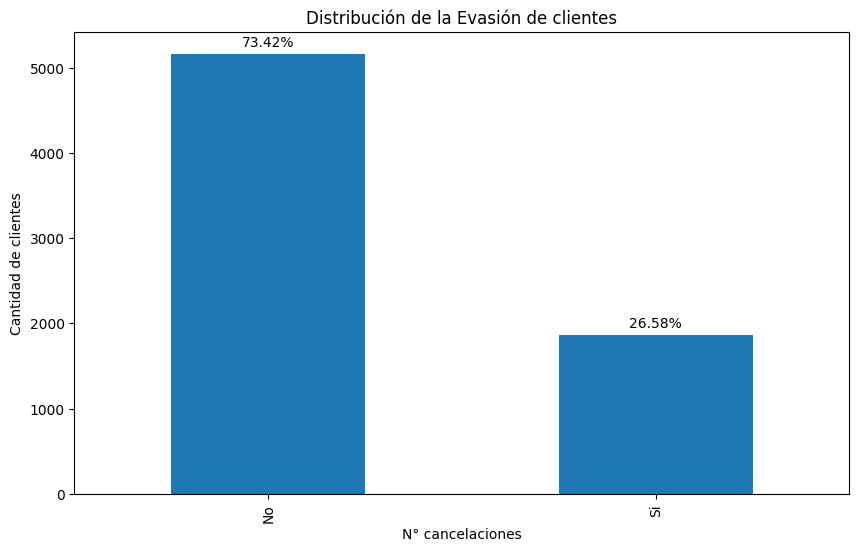

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
cancelaciones = dfn_telecomx['Churn'].value_counts()
porcentaje_cancelaciones = (cancelaciones / len(dfn_telecomx)) * 100

ax = cancelaciones.plot(kind = 'bar')
plt.title('Distribución de la Evasión de clientes')
plt.ylabel('Cantidad de clientes')
plt.xlabel('N° cancelaciones')

#graficar porcentajes
for i,porcentaje in enumerate(porcentaje_cancelaciones):
  ax.text(i, cancelaciones.iloc[i]+50, f'{porcentaje:.2f}%', ha='center', va='bottom')
plt.show()

In [24]:
import plotly.express as px

#creacion de gráfico
fig = px.histogram(dfn_telecomx, x='genero', text_auto=True, color='Churn', barmode = 'group')
fig.show()

In [25]:
fig = px.histogram(dfn_telecomx, x='tiempo_contrato', text_auto=True, color='Churn', barmode = 'group')
fig.show()

In [26]:
fig = px.histogram(dfn_telecomx, x='contrato', text_auto=True, color='Churn', barmode = 'group')
fig.show()

In [27]:
fig = px.histogram(dfn_telecomx, x='total_cobrado', text_auto=True, color='Churn', barmode = 'group')
fig.show()

In [28]:
fig = px.histogram(dfn_telecomx, x='valor_mensual', text_auto=True, color='Churn', barmode = 'group')
fig.show()

In [29]:
fig = px.histogram(dfn_telecomx, x='metodo_de_pago', text_auto=True, color='Churn', barmode = 'group')
fig.show()

In [30]:
fig = px.histogram(dfn_telecomx, x='tipo_de_internet', text_auto=True, color='Churn', barmode = 'group')
fig.show()

In [31]:
fig = px.histogram(dfn_telecomx, x = ['servicio_telefono'], text_auto=True, color='Churn', barmode = 'group')
fig.show()

In [32]:
fig = px.histogram(dfn_telecomx, x = ['tiene_dependientes'], text_auto=True, color='Churn', barmode = 'group')
fig.show()

In [33]:
fig = px.histogram(dfn_telecomx, x = ['tiene_pareja'], text_auto=True, color='Churn', barmode = 'group')
fig.show()

In [34]:
fig = px.histogram(dfn_telecomx, x = ['tiempo_contrato'], text_auto=True, color='tiene_pareja', barmode = 'group')
fig.show()

In [35]:
fig = px.histogram(dfn_telecomx, x = ['tiempo_contrato'], text_auto=True, color='tiene_dependientes', barmode = 'group')
fig.show()

In [36]:
fig = px.histogram(dfn_telecomx, x = ['streaming_tv'], text_auto=True, color='Churn', barmode = 'group')
fig.show()

#📄Informe final

###Limpieza y Tratamiento de Datos:
Importar la biblioteca de pandas para poder extraer los datos del json.
`import pandas as pd`

Se importan los datos del archivo json y se normalizan para transformar la estructura de datos jerárquica y anidada en un formato tabular plano y estructurado para facilitar el anpalisis y manipulación de datos con pandas.
Debido a que el archivo que se está tratando fue cargado al cuaderno y no es trabajado directamente con la url del archivo, el método para normalizarlo fue ligeramente diferente a como de costumbre, teniendo que crear variables de cada columna que almacenará cada columna normalizada, para postierormente anidarlas al data frame de la siguiente manera:



```
n_customer = pd.json_normalize(df_telecomx['customer'])
n_phone = pd.json_normalize(df_telecomx['phone'])
n_internet = pd.json_normalize(df_telecomx['internet'])
n_account = pd.json_normalize(df_telecomx['account'])

dfn_telecomx = pd.concat([df_telecomx['customerID'],df_telecomx['Churn'], n_customer,n_phone, n_internet, n_account ], axis=1)
```



Se analizan los datos de la tabla para comprender su estructura, tipos de datos e identificar columnas clave que nos permitan cumplir el objetivo.

Enseguida se buscan incongruencias con los tipos de datos en la tabla, ya sea un mal formato en el tipo de dato (que sea del tipo object en lugar de float), datos faltantes/nulos y espacios en blanco que afecten el poder manipular los datos. Revisar los datos únicos de cada columna es de suma importancia para entender cuáles son los valores que causan problemas con el tratamiento de nuestros datos y si cuenta con datos duplicados:

Para conocer valores únicos en cada columna:
```
for column in dfn_telecomx.columns:
    print(f"Column: {column}")
    print(dfn_telecomx[column].nunique())
    print(dfn_telecomx[column].unique())
    print("\n")
```

Para buscar valores duplicados:

```
# Contar el número de filas completamente duplicadas
num_duplicate_rows = dfn_telecomx.duplicated().sum()
print(f"Número de filas completamente duplicadas: {num_duplicate_rows}")

# Mostrar las filas completamente duplicadas (todas las ocurrencias excepto la primera)
duplicate_rows = dfn_telecomx[dfn_telecomx.duplicated(keep=False)]
print("\nFilas completamente duplicadas (todas las ocurrencias):")
display(duplicate_rows)
```



Para datos vacíos, puesto que conocemos que el caracter en blanco está escrito de la siguiente manera '' sue puede emplear la siguiente línea de código:

`dfn_telecomx.isin(['']).sum()`

Si se desea usar una alternativa más robusta que busque otras formas de espacios en blanco, se puede emplear la siguiente:



`dfn_telecomx = dfn_telecomx[dfn_telecomx['Churn'].str.strip() != '']`



Para contabilizar los datos nulos será asi:

`dfn_telecomx.isnull().sum()`

Una vez localizados se procede a tratarlos, modificando el tipo de dato por el correspondiente y eliminando los espacios en blanco de la tabla, puesto que sabemos que nuestra columna "Churn" es la única que posee espacios en blanco de esta forma '', es posible contarlas para cada columna de la siguiente manera:

`dfn_telecomx.isin(['']).sum()`

Mientras que para los datos nulos será asi:

`dfn_telecomx.isnull().sum()`

Se realiza una verificación para corroborar el correcto tratamiento de ello

Como parte opcional, se calculó una nueva columna con el nombre "Cuentas_Diarias" tomando para cada fila su cobro mensual dividido por 30 días.
Asi mismo se pude estandarizar nuestro data frame para facilitar su comprensión, creando una variable para almacenar en forma de diccionario en cada llave, será su nombre original de cada columna y como valor, su nombre traducido.
Además de sustituir las cadenas de texto tales como "Yes" y "No" a un formato booleano (1 y 0) para futuros análisis.

🔹

###Análisis Exploratorio de Datos:
Se reaiza un análisis exploratorio tratando de identificar patrones o perfiles de nuestros clientes cuyo índice de cancelación son alarmantes, para ello se empleará mayormente los datos de la columna "Churn"

En primera instancia conocemos el porcentaje de nuestras cancelaciones de la figura 1.1




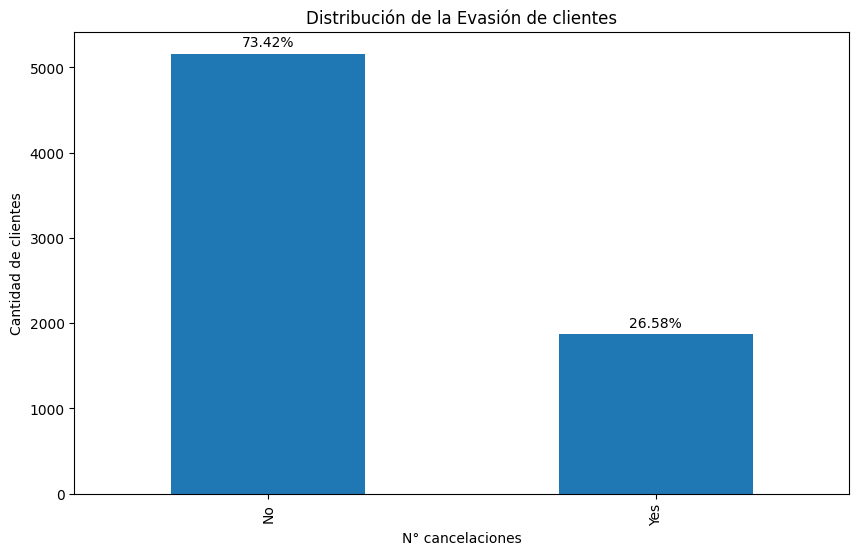

*figura 1.1 Distribución de la evasión de clientes*

Empezamos a analizar si puede ser un problema demográfico, como relacionado al género o si es porque son personas solteras o con alguna dependiente:
Para ello se observaron las siguientes situaciones:

* Abandono por género *(fig. 2.1)*
* Abandono por personas con/sin pareja *(fig 2.2)*
* Abandono por personas con/sin dependientes *(fig. 2.3)*

* Abandonos por tiempo de contrato *(fig. 3.1)*
* Abandonos por tipo de contrato *(fig. 3.2)*
* Tiempo de contrato de personas con/sin dependientes *(fig. 3.3)*
* Tiempo de personas con/sin pareja *(fig. 3.4)*

* Abandonos por total cobrado *(fig. 4.1)*
* Abandonos por tipo de pago *(fig. 4.2)*
* Abandonos por valor mensual *(fig. 4.3)*

* Abandonos de personas con/sin streaming de peliculas *(fig. 5.1)*
* Abandonos de personas con/sin streaming de TV *(fig. 5.2)*
* Abandonos de personas con/sin servicio telefónico *(fig. 5.3)*

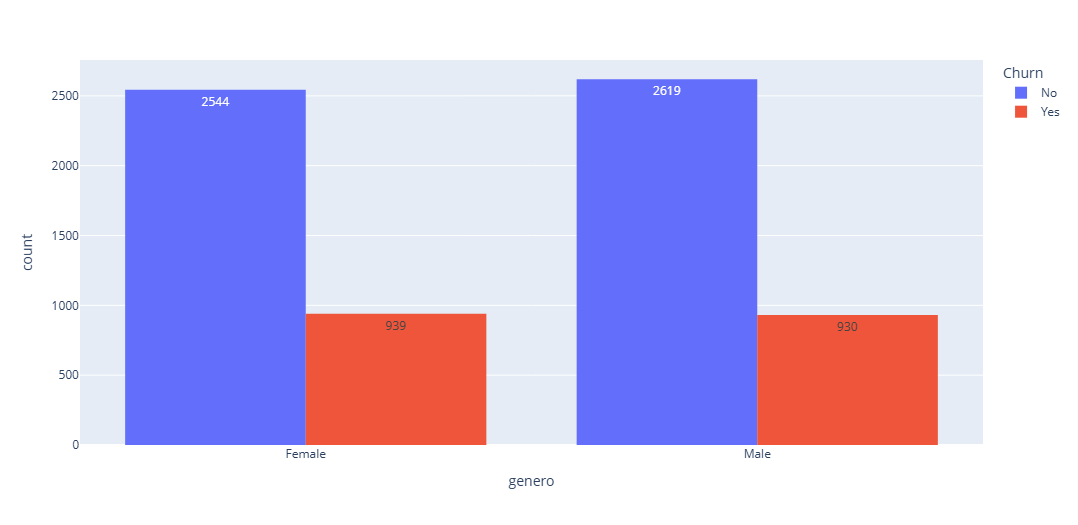

*Fig 2.1 Abandono por género*


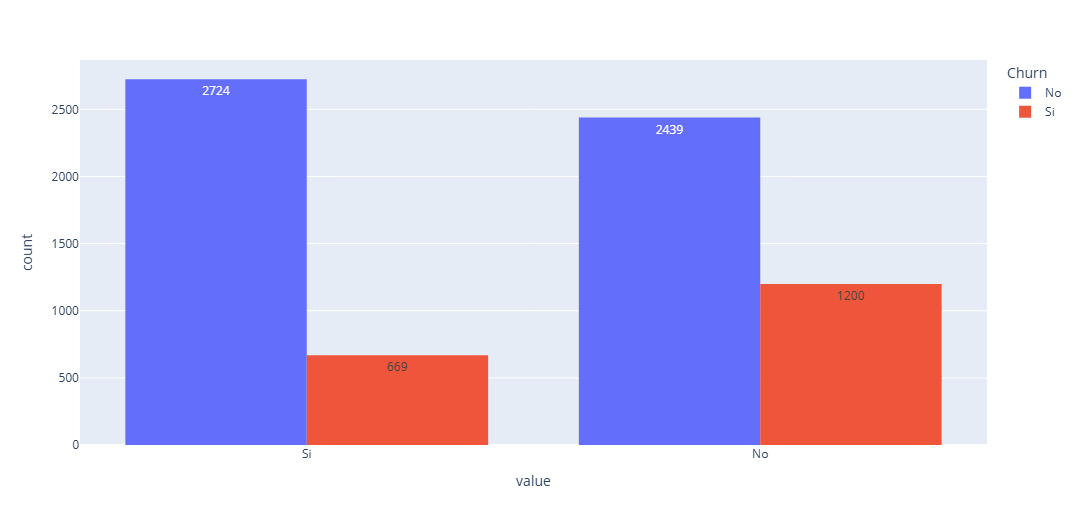

*Fig. 2.2: Abandono por personas con/sin pareja*

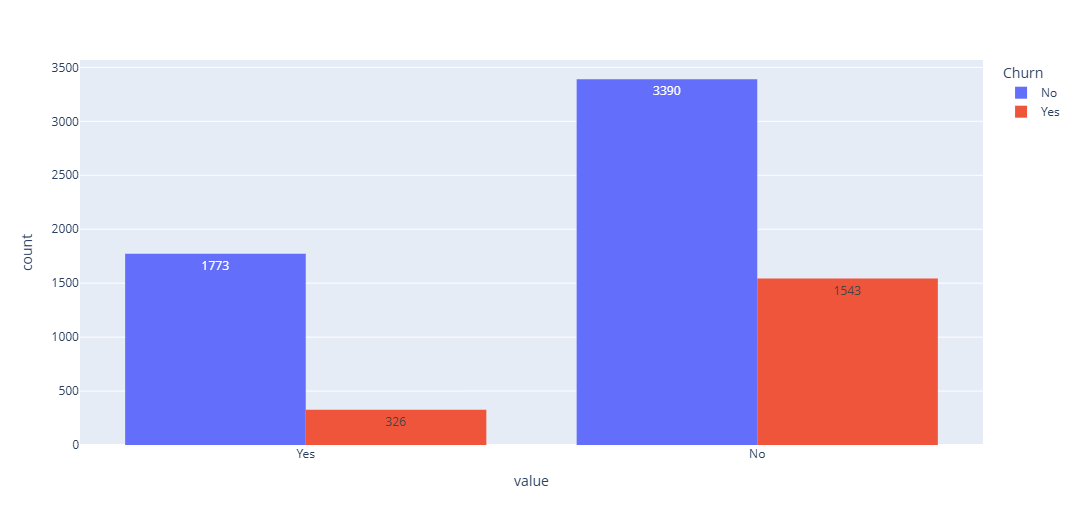

*Fig. 2.3 Abandono por personas con/sin dependientes*


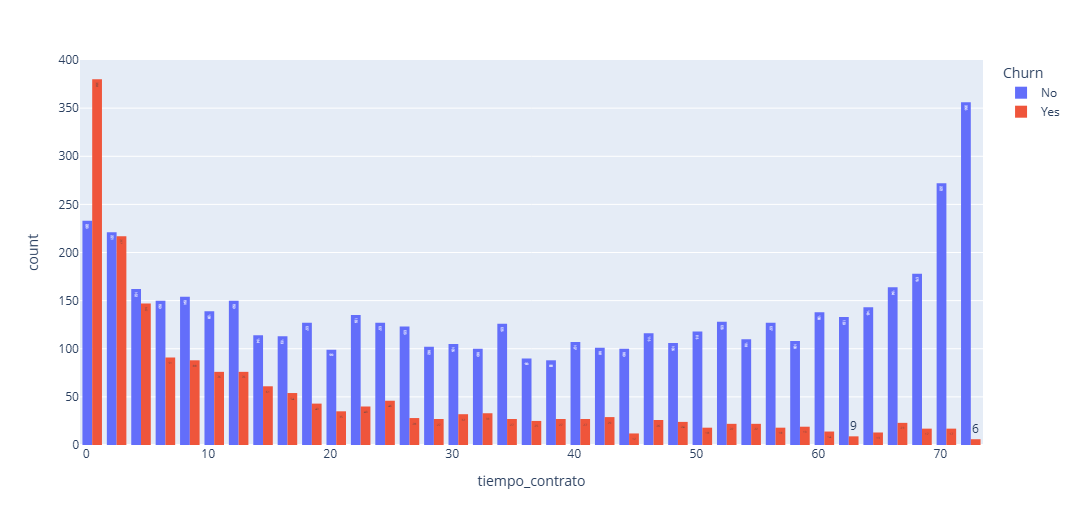

*Fig 3.1: Abandonos por tiempo de contrato*


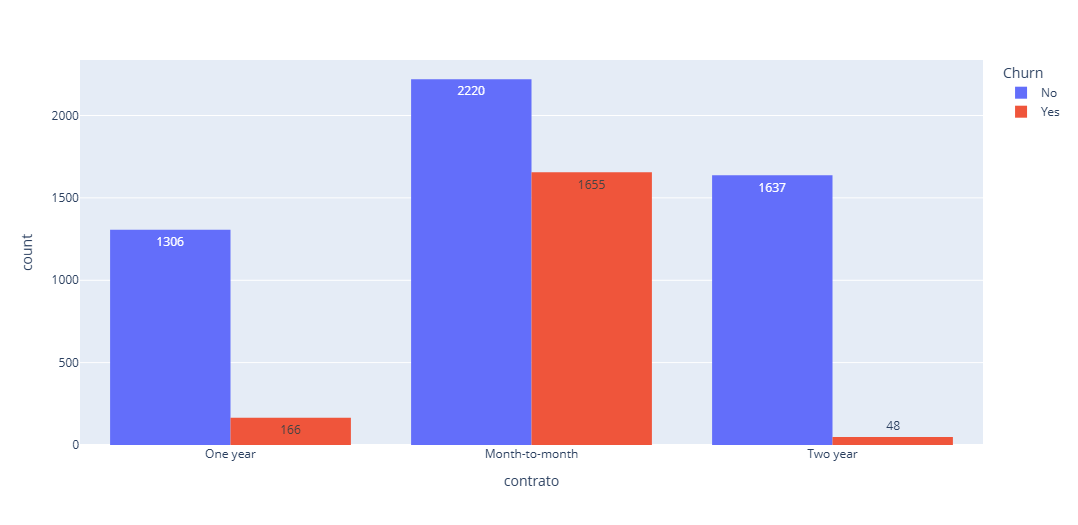

*Fig 3.2: Abandonos por tipo de contrato*

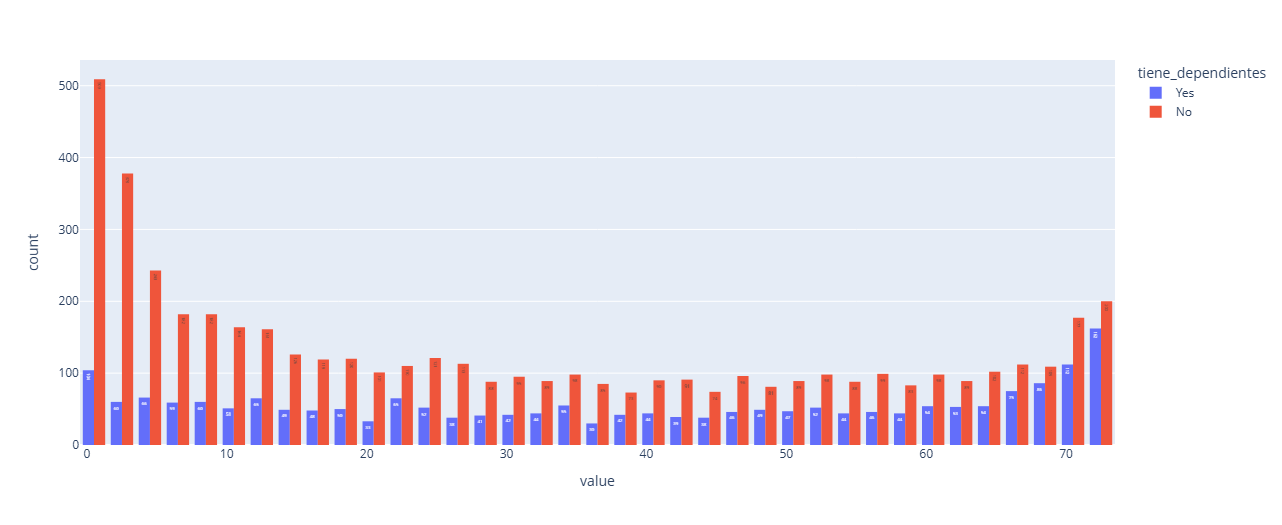

* Fig. 3.3: Tiempo de contrato de personas con/sin dependientes*

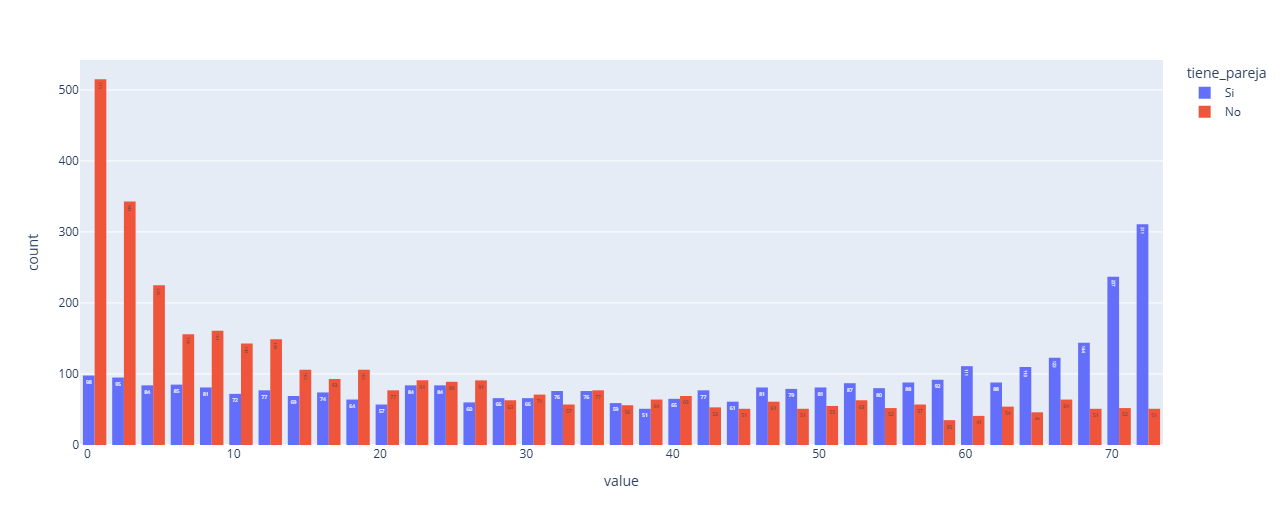

*Fig 3.4: Tiempo de personas con/sin pareja*

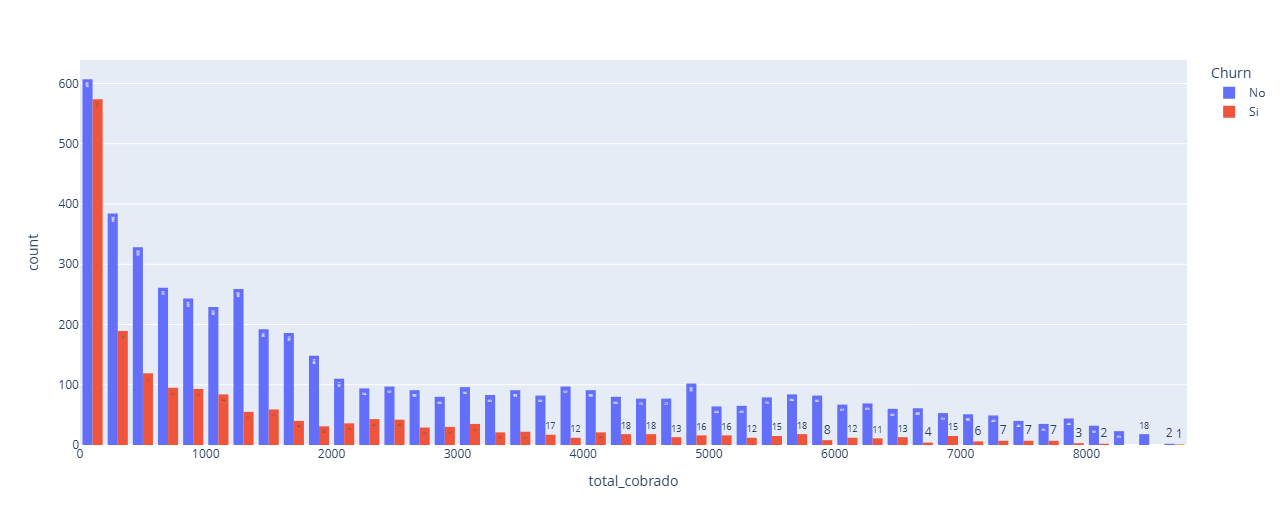

*Fig. 4.1: Abandonos por total cobrado*


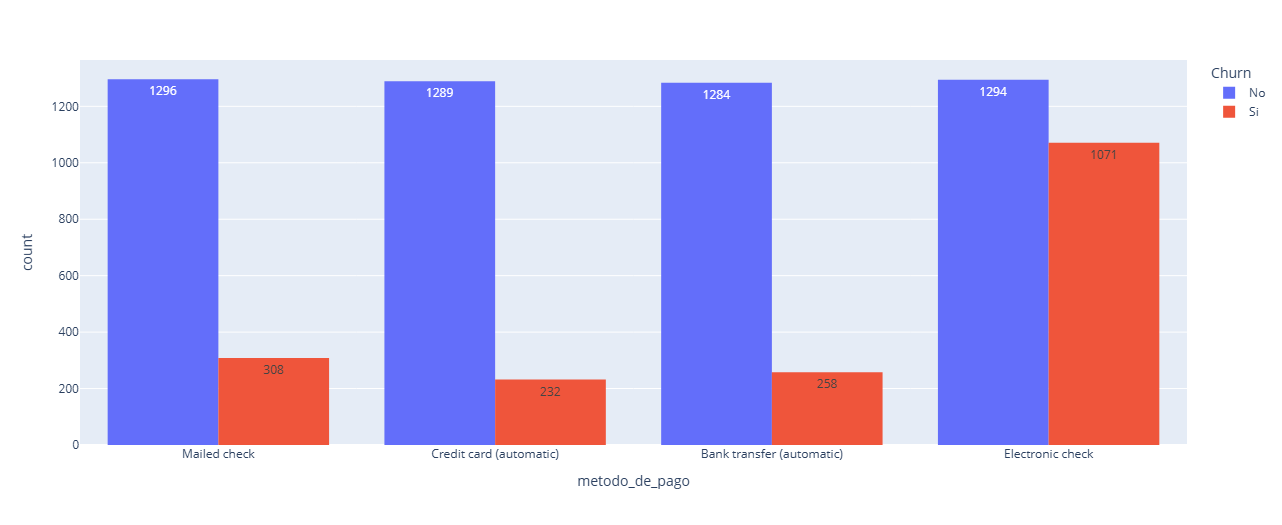

*Fig. 4.2: Abandonos por tipo de pago*


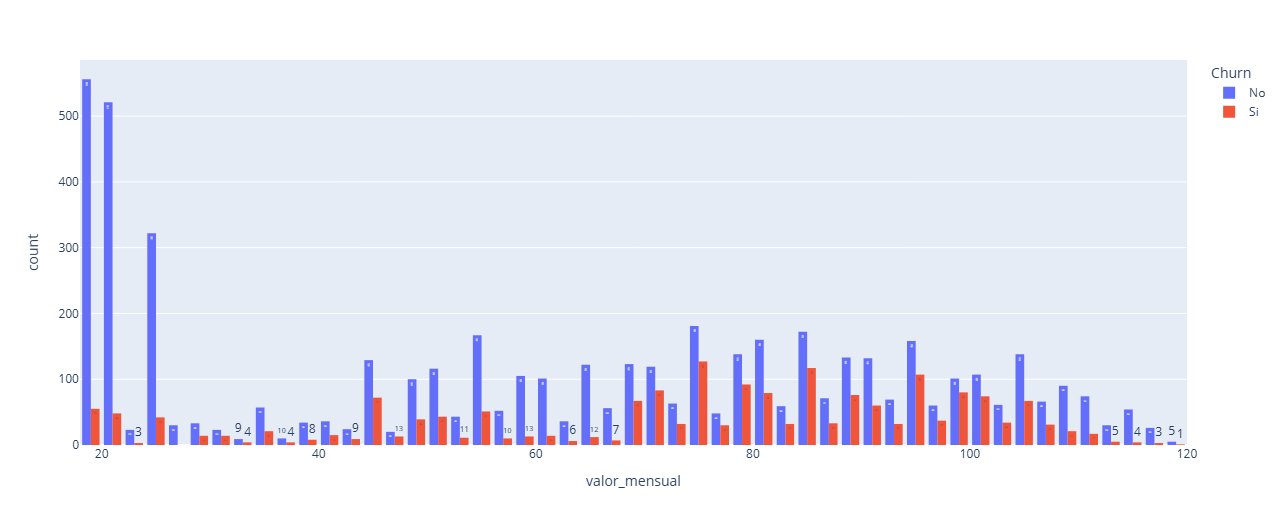

*Fig. 4.3: Abandonos por valor mensual*


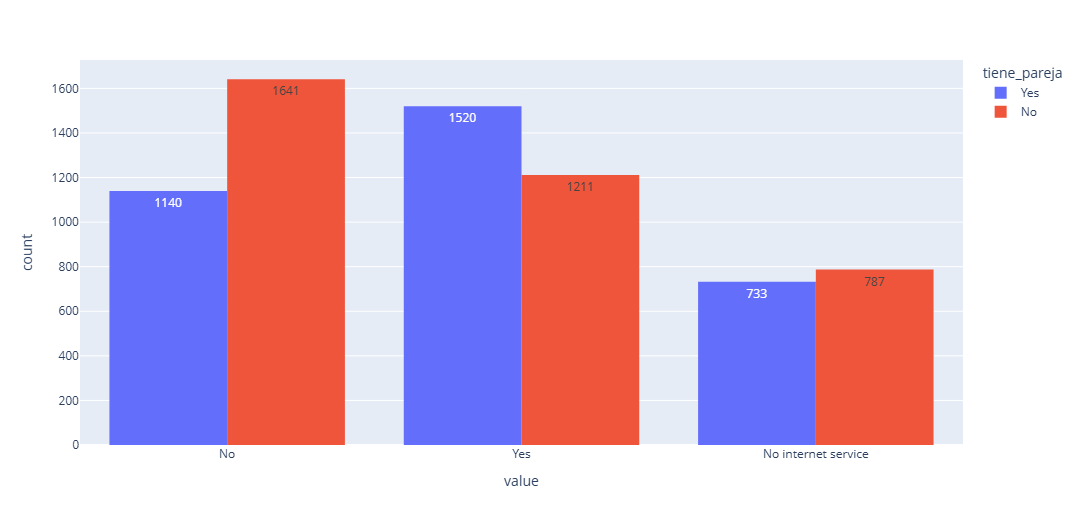

*Fig 5.1: Abandonos de personas con/sin streaming de peliculas*


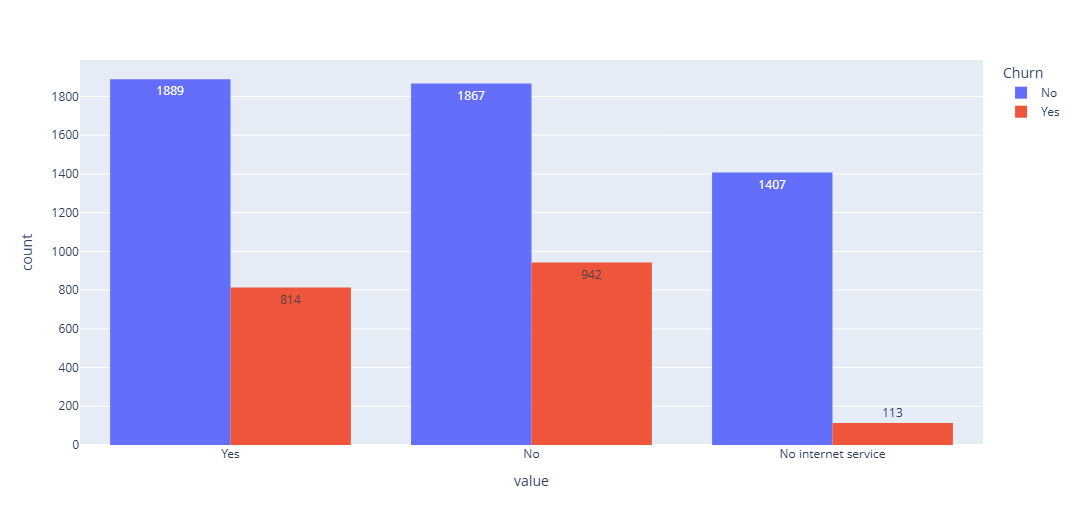

*Fig. 5.2: Abandonos de personas con/sin streaming de TV*

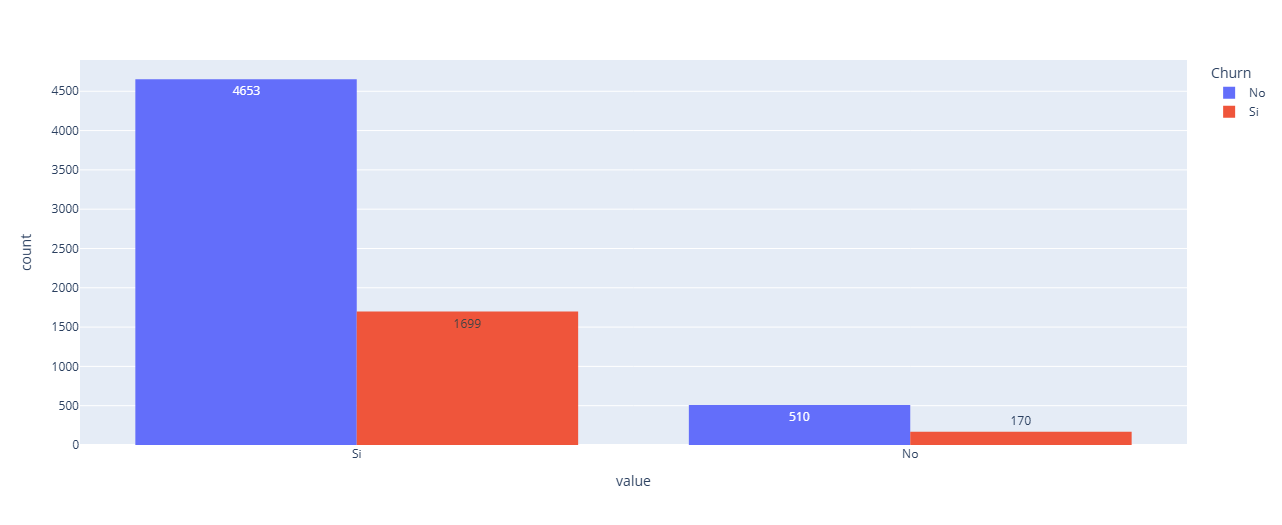

*Fig 5.3 Abandonos de personas con/sin servicio telefónico*

De ello podemos observar lo siguiente:

* La mayoría de las cancelaciones suelen darse en contratos con periodos cortos, como een el mes a mes.

* Las personas solteras suelen hacer contratos mas cortos, mientras que las personas con pareja son más largos. Un caso muy similar a cuando las personas tienen dependientes, pero en menor escala.

* Los usuarios que se les cobra menos son los que mayormente cancelan, lo que podría significar que es debido a la duración del contrato y que no prueban los demás servicios que ofrece la compañia, como el soporte técnico o los de streaming.

* La mayoría de cancelaciones se produce dentro del rango de 70 - 100

* Las personas con pago mediante cheque electrónico representan la mayoría de las cancelaciones

* Personas con fibra optica tambien tienen un alto indice de cancelaciones con respecto a los otros servicios o tipos de internet que se ofrecen.

* Las personas que cuentan con servicio telefónico tambien tienen una cantidad significante de cancelaciones

* Las personas que no tienen dependientes tambien tienen un alto indice de abandono, lo mismo sucede con las personas que no tienen pareja.

* Personas que carecen del servicio de internet suelen quedarse.

###Conclusiones e Insights: Resume los principales hallazgos y cómo estos datos pueden ayudar a reducir la evasión.

# 📊 Análisis de Perfil de Abandono (Churn Rate)

Este análisis detalla el perfil del cliente con mayor probabilidad de cancelar sus servicios y las conclusiones estratégicas derivadas de los datos operativos de la compañía.

---

## 👤 Perfil del Cliente en Riesgo ("Persona Churn")

Basado en los patrones detectados, el cliente con mayor propensión al abandono cumple con las siguientes características:

* **Situación Personal:** Persona **soltera y sin dependientes**. Representa un perfil con mayor movilidad y menor resistencia al cambio de proveedor.
* **Preferencia Contractual:** Opta por la flexibilidad total mediante contratos **mes a mes**. Evita compromisos a largo plazo.
* **Configuración de Servicio:** Usuario de **Fibra Óptica** y **Servicio Telefónico**. Curiosamente, a pesar de tener servicios avanzados, son los más propensos a irse.
* **Comportamiento de Pago:** Utiliza **cheque electrónico** como método de pago principal.
* **Nivel de Engagement:** Usuario de "bajo costo" que **no utiliza servicios de valor añadido** (streaming, soporte técnico). Su relación con la marca es puramente transaccional.

---

## Conclusiones Estratégicas

### 1. La Brecha de Valor en la Fibra Óptica
A pesar de ser el producto estrella tecnológicamente, la **Fibra Óptica** presenta el mayor índice de cancelaciones. Esto sugiere que:
* El precio podría ser demasiado alto tras el periodo promocional.
* La competencia está captando a estos usuarios con ofertas agresivas.
* La expectativa de velocidad no compensa la falta de otros beneficios.

### 2. El "Aislamiento" del Cliente es un Factor Crítico
Existe una correlación directa entre el uso de servicios adicionales y la retención:
> **Conclusión:** Los clientes que no prueban el soporte técnico o el streaming no generan "raíces" con la empresa. Al no haber interacción humana o consumo de contenido exclusivo, el servicio se vuelve un *commodity* fácil de reemplazar.

### 3. El Umbral Crítico (Rango 70 - 100)
La mayor parte de las cancelaciones se concentran en este rango (posiblemente referido al monto de facturación o días de antigüedad). Este es el **momento de la verdad** donde el cliente evalúa si el beneficio percibido justifica el gasto recurrente.

### 4. Estabilidad vs. Volatilidad
* **Estabilidad:** Los clientes con pareja y dependientes funcionan como un ancla; prefieren contratos largos y la seguridad del servicio.
* **Volatilidad:** Los clientes sin internet tienden a quedarse más tiempo, lo que sugiere que el servicio básico de telefonía es percibido como una necesidad estable, mientras que el internet es un mercado mucho más volátil y competitivo.

---

## Recomendaciones Proactivas

1.  **Migración de Pago:** Incentivar el cambio de "Cheque Electrónico" a "Cargo Automático" para reducir la fricción mensual del pago.
2.  **Estrategia de Cross-selling:** Fomentar el uso de soporte técnico preventivo o pruebas gratuitas de streaming para aumentar la "adherencia" del cliente.
3.  **Fidelización del Soltero:** Crear planes intermedios que ofrezcan beneficios de largo plazo sin la rigidez de un contrato anual para captar al perfil joven/soltero.